Columns: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')
Target Column: y

===== CROSS VALIDATION (ROC-AUC) =====
Logistic Regression: Mean AUC = 0.8560
Decision Tree: Mean AUC = 0.6816
Naive Bayes: Mean AUC = 0.7996
KNN: Mean AUC = 0.7600
SVM: Mean AUC = 0.8280

===== TEST SET: AUC & ACCURACY =====
Logistic Regression: Accuracy = 0.8829  |  Test AUC = 0.8545
Decision Tree: Accuracy = 0.8685  |  Test AUC = 0.6873
Naive Bayes: Accuracy = 0.8409  |  Test AUC = 0.8195
KNN: Accuracy = 0.8906  |  Test AUC = 0.7434
SVM: Accuracy = 0.8972  |  Test AUC = 0.8299


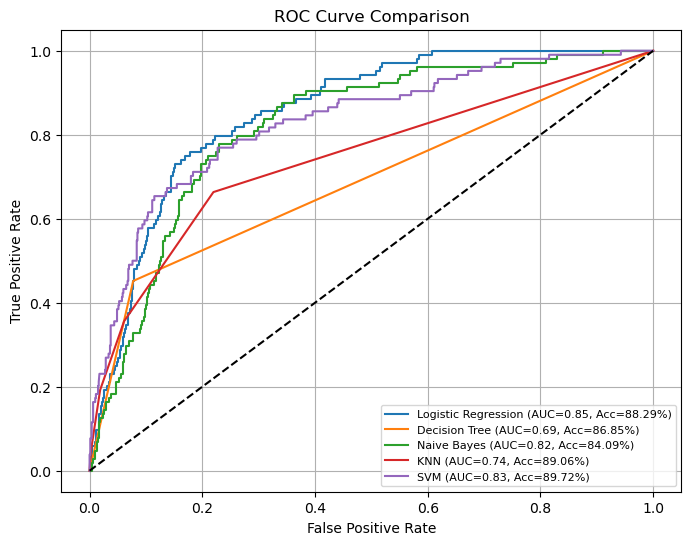


===== FINAL MODEL RANKING =====
              Model CV AUC Accuracy
Logistic Regression 0.8560   88.29%
                SVM 0.8280   89.72%
        Naive Bayes 0.7996   84.09%
                KNN 0.7600   89.06%
      Decision Tree 0.6816   86.85%


In [10]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc,accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# =========================
# 2. LOAD DATASET (FIXED)
# =========================
df = pd.read_csv("bank.csv", sep=";")   # important fix

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# =========================
# 3. TARGET FIX
# =========================
# Automatically detect target column
target_col = None
for col in df.columns:
    if col.lower() in ["y", "deposit", "subscribed", "response"]:
        target_col = col
        break

if target_col is None:
    raise Exception("Target column not found!")

print("Target Column:", target_col)

# =========================
# 4. PREPROCESSING
# =========================
# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

X = df.drop(target_col, axis=1)
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 5. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

# =========================
# 6. CROSS-VALIDATION
# =========================
print("\n===== CROSS VALIDATION (ROC-AUC) =====")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores.mean()
    print(f"{name}: Mean AUC = {scores.mean():.4f}")

# =========================
# 7. ROC CURVE + ACCURACY  ← UPDATED
# =========================
from sklearn.metrics import accuracy_score   # add this at top

print("\n===== TEST SET: AUC & ACCURACY =====")
plt.figure(figsize=(8, 6))

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)          # for accuracy
    y_prob = model.predict_proba(X_test)[:, 1]  # for AUC

    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f}, Acc={acc:.2%})")
    print(f"{name}: Accuracy = {acc:.4f}  |  Test AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.grid()
plt.show()

# =========================
# 8. FINAL RESULTS  ← UPDATED
# =========================
results_df = pd.DataFrame({
    "Model":     list(cv_results.keys()),
    "CV AUC":   list(cv_results.values()),
    "Accuracy": [accuracy_results[m] for m in cv_results.keys()],
})
results_df = results_df.sort_values(by="CV AUC", ascending=False).reset_index(drop=True)
results_df["CV AUC"]   = results_df["CV AUC"].map(lambda x: f"{x:.4f}")
results_df["Accuracy"] = results_df["Accuracy"].map(lambda x: f"{x:.2%}")

print("\n===== FINAL MODEL RANKING =====")
print(results_df.to_string(index=False))

Columns: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')
Target Column: y

===== CROSS VALIDATION (ROC-AUC) =====
Logistic Regression: Mean AUC = 0.8560
Decision Tree: Mean AUC = 0.6816
Naive Bayes: Mean AUC = 0.7996
KNN: Mean AUC = 0.7600
SVM: Mean AUC = 0.8280

===== TEST SET: AUC & ACCURACY =====
Logistic Regression: Accuracy = 0.8829  |  Test AUC = 0.8545
Decision Tree: Accuracy = 0.8685  |  Test AUC = 0.6873
Naive Bayes: Accuracy = 0.8409  |  Test AUC = 0.8195
KNN: Accuracy = 0.8906  |  Test AUC = 0.7434
SVM: Accuracy = 0.8972  |  Test AUC = 0.8299


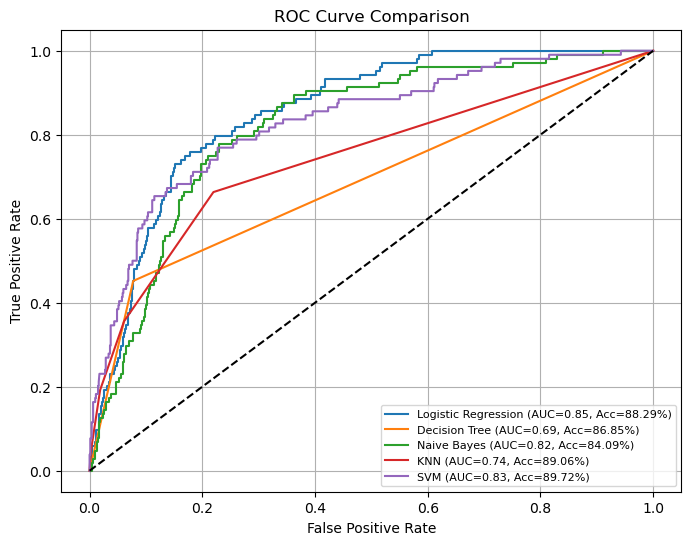


===== FINAL MODEL RANKING =====
              Model CV AUC Accuracy
Logistic Regression 0.8560   88.29%
                SVM 0.8280   89.72%
        Naive Bayes 0.7996   84.09%
                KNN 0.7600   89.06%
      Decision Tree 0.6816   86.85%


In [10]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc,accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# =========================
# 2. LOAD DATASET (FIXED)
# =========================
df = pd.read_csv("bank.csv", sep=";")   # important fix

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)

# =========================
# 3. TARGET FIX
# =========================
# Automatically detect target column
target_col = None
for col in df.columns:
    if col.lower() in ["y", "deposit", "subscribed", "response"]:
        target_col = col
        break

if target_col is None:
    raise Exception("Target column not found!")

print("Target Column:", target_col)

# =========================
# 4. PREPROCESSING
# =========================
# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

X = df.drop(target_col, axis=1)
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 5. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

# =========================
# 6. CROSS-VALIDATION
# =========================
print("\n===== CROSS VALIDATION (ROC-AUC) =====")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores.mean()
    print(f"{name}: Mean AUC = {scores.mean():.4f}")

# =========================
# 7. ROC CURVE + ACCURACY  ← UPDATED
# =========================
from sklearn.metrics import accuracy_score   # add this at top

print("\n===== TEST SET: AUC & ACCURACY =====")
plt.figure(figsize=(8, 6))

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)          # for accuracy
    y_prob = model.predict_proba(X_test)[:, 1]  # for AUC

    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f}, Acc={acc:.2%})")
    print(f"{name}: Accuracy = {acc:.4f}  |  Test AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.grid()
plt.show()

# =========================
# 8. FINAL RESULTS  ← UPDATED
# =========================
results_df = pd.DataFrame({
    "Model":     list(cv_results.keys()),
    "CV AUC":   list(cv_results.values()),
    "Accuracy": [accuracy_results[m] for m in cv_results.keys()],
})
results_df = results_df.sort_values(by="CV AUC", ascending=False).reset_index(drop=True)
results_df["CV AUC"]   = results_df["CV AUC"].map(lambda x: f"{x:.4f}")
results_df["Accuracy"] = results_df["Accuracy"].map(lambda x: f"{x:.2%}")

print("\n===== FINAL MODEL RANKING =====")
print(results_df.to_string(index=False))